**Importing the dataset**



In [1]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("rafsanmahmud333333/cifar-10-attacked-dataset")



100%|██████████| 82.0M/82.0M [00:01<00:00, 76.3MB/s]

Extracting files...


**Data Preprocessing**

In [2]:
import os
import cv2
import pandas as pd
import numpy as np

# Set up paths to the dataset directory splits
base_path = os.path.join(path, "cifar10")
test_dir = os.path.join(base_path, "test")
clean_dir = os.path.join(test_dir, "clean")
fgsm_dir = os.path.join(test_dir, "fgsm")

# Load the test metadata to get the matching filenames and true labels
metadata_path = os.path.join(test_dir, "metadata_test(fgsm, bim, cANDw).csv")

if not os.path.exists(metadata_path):
    print(f"Error: Missing metadata file at {metadata_path}")
else:
    df_meta = pd.read_csv(metadata_path)

    # Filter metadata rows to select only the FGSM adversarial attack samples
    df_fgsm_meta = df_meta[df_meta['attack_type'] == 'fgsm']

    # Arrays to store the processed image matrices, noise residuals, and target labels
    clean_images = []
    fgsm_images = []
    noise_residuals = []
    labels = []

    print(f"Running data loading and image preprocessing for {len(df_fgsm_meta)} samples...")

    for index, row in df_fgsm_meta.iterrows():
        # Extract the raw filename string from the metadata path column
        full_path_str = row['image_path']
        filename = os.path.basename(full_path_str)
        true_label = row['original_label']

        clean_img_path = os.path.join(clean_dir, filename)
        fgsm_img_path = os.path.join(fgsm_dir, filename)

        if os.path.exists(clean_img_path) and os.path.exists(fgsm_img_path):
            # Load images as 2D coordinate matrices (uint8 arrays in BGR format)
            bgr_clean = cv2.imread(clean_img_path)
            bgr_fgsm = cv2.imread(fgsm_img_path)

            # Enforce identical M x N spatial dimensions (32x32)
            if bgr_clean.shape[:2] != (32, 32):
                bgr_clean = cv2.resize(bgr_clean, (32, 32), interpolation=cv2.INTER_AREA)
            if bgr_fgsm.shape[:2] != (32, 32):
                bgr_fgsm = cv2.resize(bgr_fgsm, (32, 32), interpolation=cv2.INTER_AREA)

            # Convert color space from BGR channel layout to standard RGB
            rgb_clean = cv2.cvtColor(bgr_clean, cv2.COLOR_BGR2RGB)
            rgb_fgsm = cv2.cvtColor(bgr_fgsm, cv2.COLOR_BGR2RGB)

            # Normalize pixel intensity values from [0, 255] to [0.0, 1.0] float space
            norm_clean = rgb_clean.astype(np.float32) / 255.0
            norm_fgsm = rgb_fgsm.astype(np.float32) / 255.0

            # Perform element-wise subtraction to isolate the adversarial noise matrix η(x,y)
            noise_matrix = norm_fgsm - norm_clean

            # Append matrices and labels to their respective lists
            clean_images.append(norm_clean)
            fgsm_images.append(norm_fgsm)
            noise_residuals.append(noise_matrix)
            labels.append(true_label)

    # Convert the collected image structures into final NumPy tensors
    X_clean = np.array(clean_images)
    X_fgsm = np.array(fgsm_images)
    X_noise = np.array(noise_residuals)
    y_test = np.array(labels)

    # Verification summary to check dataset tensor shapes
    print("\n--- Preprocessing Pipeline Verification ---")
    print(f"X_clean Matrix Shape : {X_clean.shape}")
    print(f"X_fgsm Matrix Shape  : {X_fgsm.shape}")
    print(f"X_noise Matrix Shape : {X_noise.shape}")
    print(f"y_test Target Shape  : {y_test.shape}")

Running data loading and image preprocessing for 500 samples...

--- Preprocessing Pipeline Verification ---
X_clean Matrix Shape : (500, 32, 32, 3)
X_fgsm Matrix Shape  : (500, 32, 32, 3)
X_noise Matrix Shape : (500, 32, 32, 3)
y_test Target Shape  : (500,)


**Evaluation and Analysis**

Filtering completed.
X_gaussian shape : (500, 32, 32, 3)
X_bilateral shape: (500, 32, 32, 3)
X_jpeg shape     : (500, 32, 32, 3)

--- Evaluation Results ---


,Method,Average PSNR,Average SSIM
0,FGSM Attacked Image,20.191057,0.696280
1,Gaussian Blur,22.643323,0.806706
2,Bilateral Filter,22.817033,0.817234
3,JPEG Compression,21.607498,0.759519


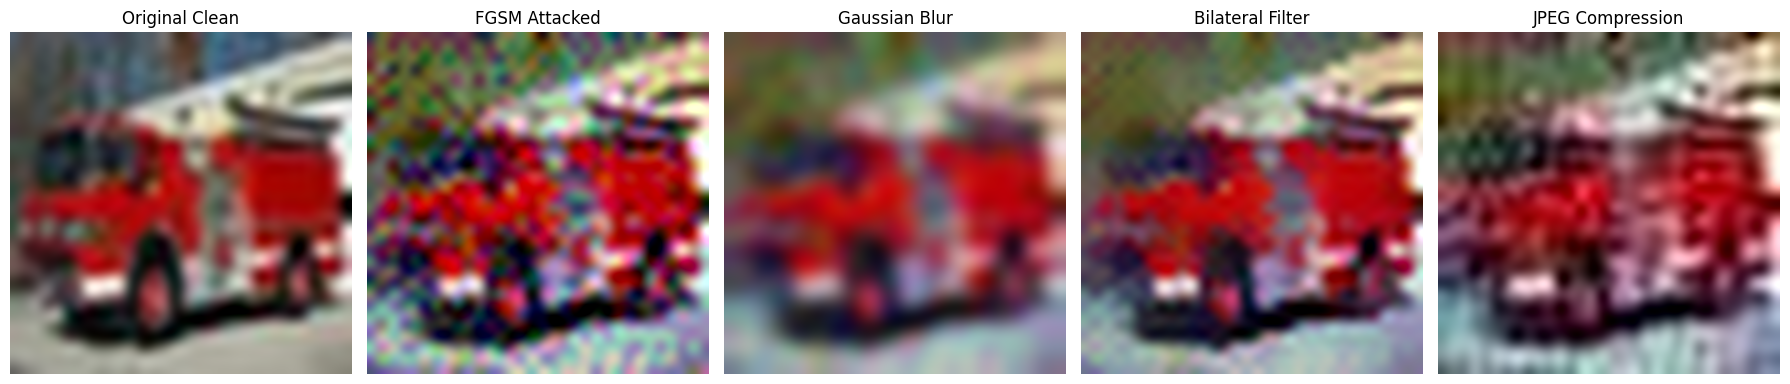


--- Analysis ---
The FGSM attacked images were used as the baseline for evaluation.
Gaussian Blur, Bilateral Filter, and JPEG Compression were applied as image processing defense techniques.
Each processed image was compared with its corresponding original clean image using PSNR and SSIM.
Higher PSNR indicates better pixel-level similarity, while higher SSIM indicates better structural similarity.
The best performing technique is Bilateral Filter with PSNR = 22.82 and SSIM = 0.817.
This indicates that the selected technique achieved the best balance between reducing adversarial noise and preserving important image details.


In [9]:
# VI. Evaluation and Analysis
# Image Processing Defense Comparison

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# -----------------------------
# 1. Define Image Processing Techniques
# -----------------------------

def apply_gaussian(image):
    return cv2.GaussianBlur(image, (3, 3), 0)

def apply_bilateral(image):
    image_uint8 = (image * 255).astype(np.uint8)

    filtered = cv2.bilateralFilter(
        image_uint8,
        d=5,
        sigmaColor=75,
        sigmaSpace=75
    )

    return filtered.astype(np.float32) / 255.0

def apply_jpeg_compression(image, quality=50):
    image_uint8 = (image * 255).astype(np.uint8)

    image_bgr = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2BGR)

    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    success, encoded_image = cv2.imencode(".jpg", image_bgr, encode_param)

    decoded_image = cv2.imdecode(encoded_image, cv2.IMREAD_COLOR)
    decoded_rgb = cv2.cvtColor(decoded_image, cv2.COLOR_BGR2RGB)

    return decoded_rgb.astype(np.float32) / 255.0


# -----------------------------
# 2. Apply Filters to FGSM Images
# -----------------------------

X_gaussian = np.array([apply_gaussian(img) for img in X_fgsm])
X_bilateral = np.array([apply_bilateral(img) for img in X_fgsm])
X_jpeg = np.array([apply_jpeg_compression(img) for img in X_fgsm])

print("Filtering completed.")
print("X_gaussian shape :", X_gaussian.shape)
print("X_bilateral shape:", X_bilateral.shape)
print("X_jpeg shape     :", X_jpeg.shape)


# -----------------------------
# 3. Evaluate Using PSNR and SSIM
# -----------------------------

def evaluate_images(clean_images, processed_images):
    psnr_scores = []
    ssim_scores = []

    for clean_img, processed_img in zip(clean_images, processed_images):

        psnr_value = peak_signal_noise_ratio(
            clean_img,
            processed_img,
            data_range=1.0
        )

        ssim_value = structural_similarity(
            clean_img,
            processed_img,
            channel_axis=2,
            data_range=1.0
        )

        psnr_scores.append(psnr_value)
        ssim_scores.append(ssim_value)

    return np.mean(psnr_scores), np.mean(ssim_scores)


methods = {
    "FGSM Attacked Image": X_fgsm,
    "Gaussian Blur": X_gaussian,
    "Bilateral Filter": X_bilateral,
    "JPEG Compression": X_jpeg
}

results = []

for method_name, image_set in methods.items():
    avg_psnr, avg_ssim = evaluate_images(X_clean, image_set)

    results.append({
        "Method": method_name,
        "Average PSNR": avg_psnr,
        "Average SSIM": avg_ssim
    })

results_df = pd.DataFrame(results)

print("\n--- Evaluation Results ---")
display(results_df)


# -----------------------------
# 4. Display Visual Comparison
# -----------------------------

sample_index = 23

images_to_show = [
    X_clean[sample_index],
    X_fgsm[sample_index],
    X_gaussian[sample_index],
    X_bilateral[sample_index],
    X_jpeg[sample_index]
]

titles = [
    "Original Clean",
    "FGSM Attacked",
    "Gaussian Blur",
    "Bilateral Filter",
    "JPEG Compression"
]

plt.figure(figsize=(18, 5))

for i, img in enumerate(images_to_show):
    plt.subplot(1, 5, i + 1)
    plt.imshow(
    np.clip(img, 0, 1),
    interpolation='lanczos'
)
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


# -----------------------------
# 5. Print Final Analysis
# -----------------------------

best_row = results_df.iloc[1:].sort_values(
    by=["Average PSNR", "Average SSIM"],
    ascending=False
).iloc[0]

print("\n--- Analysis ---")
print("The FGSM attacked images were used as the baseline for evaluation.")
print("Gaussian Blur, Bilateral Filter, and JPEG Compression were applied as image processing defense techniques.")
print("Each processed image was compared with its corresponding original clean image using PSNR and SSIM.")
print("Higher PSNR indicates better pixel-level similarity, while higher SSIM indicates better structural similarity.")
print(f"The best performing technique is {best_row['Method']} with PSNR = {best_row['Average PSNR']:.2f} and SSIM = {best_row['Average SSIM']:.3f}.")
print("This indicates that the selected technique achieved the best balance between reducing adversarial noise and preserving important image details.")